# OHLCV Dataset Comparison Analysis

This notebook analyzes and compares multiple OHLCV (Open, High, Low, Close, Volume) datasets to understand their underlying structures and identify factors that may influence prediction performance in the metaheuristics pipeline.

**Datasets analyzed:**
- EURUSD_H1.csv (Euro/US Dollar currency pair)
- GBPUSD_H1.csv (British Pound/US Dollar currency pair)
- EURGBP_H1.csv (Euro/British Pound currency pair)
- AAPLUSUSD_H1.csv (Apple stock vs US Dollar)
- NFLXUSUSD_H1.csv (Netflix stock vs US Dollar)
- BRENTCMDUSD_H1.csv (Brent crude oil vs US Dollar)
- USA500IDXUSD_H1.csv (S&P 500 index vs US Dollar)

**Analysis Objectives:**
1. Compare dataset sizes, date ranges, and completeness
2. Analyze price characteristics (volatility, trends, ranges)
3. Examine volume patterns and distributions
4. Assess data quality and potential issues
5. Investigate time series properties
6. Identify structural differences that may affect ML performance

## Import Libraries and Setup

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-paper')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

# Configure plotly renderer
import plotly.io as pio
pio.renderers.default = 'iframe'

## Load OHLCV Datasets

Load all available OHLCV datasets from the raw_data folder and perform initial preprocessing.

In [2]:
# Define dataset names and their descriptions
datasets_info = {
    'EURUSD_H1': 'Euro vs US Dollar (Major FX Pair)',
    'GBPUSD_H1': 'British Pound vs US Dollar (Major FX Pair)',
    'EURGBP_H1': 'Euro vs British Pound (FX Cross Pair)',
    'AAPLUSUSD_H1': 'Apple Inc. stock vs US Dollar',
    'NFLXUSUSD_H1': 'Netflix Inc. stock vs US Dollar',
    'BRENTCMDUSD_H1': 'Brent Crude Oil vs US Dollar',
    'USA500IDXUSD_H1': 'S&P 500 Index vs US Dollar'
}

# Load all datasets
datasets = {}
raw_data_path = 'raw_data'

print("Loading OHLCV datasets...")
print("=" * 50)

for filename, description in datasets_info.items():
    filepath = os.path.join(raw_data_path, f'{filename}.csv')
    try:
        # Load data
        df = pd.read_csv(filepath)

        # Standardize column names (assuming order: Date, Open, High, Low, Close, Volume)
        df.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

        # Convert Date column to datetime
        df['Date'] = pd.to_datetime(df['Date'])

        # Set Date as index
        df.set_index('Date', inplace=True)

        # Sort by date
        df.sort_index(inplace=True)

        datasets[filename] = df

        print(f"✓ {filename}: {description}")
        print(f"  Shape: {df.shape}, Date range: {df.index.min()} to {df.index.max()}")

    except Exception as e:
        print(f"✗ Error loading {filename}: {e}")

print(f"\nSuccessfully loaded {len(datasets)} datasets")
print("=" * 50)

Loading OHLCV datasets...
✓ EURUSD_H1: Euro vs US Dollar (Major FX Pair)
  Shape: (99999, 5), Date range: 2009-10-19 14:00:00 to 2025-10-29 09:00:00
✓ GBPUSD_H1: British Pound vs US Dollar (Major FX Pair)
  Shape: (99999, 5), Date range: 2009-10-16 17:00:00 to 2025-10-29 10:00:00
✓ EURGBP_H1: Euro vs British Pound (FX Cross Pair)
  Shape: (99999, 5), Date range: 2009-10-19 03:00:00 to 2025-10-29 10:00:00
✓ AAPLUSUSD_H1: Apple Inc. stock vs US Dollar
  Shape: (15404, 5), Date range: 2017-02-01 15:00:00 to 2025-10-28 19:00:00
✓ NFLXUSUSD_H1: Netflix Inc. stock vs US Dollar
  Shape: (15367, 5), Date range: 2017-02-01 15:00:00 to 2025-10-28 19:00:00
✓ BRENTCMDUSD_H1: Brent Crude Oil vs US Dollar
  Shape: (67163, 5), Date range: 2013-05-23 08:00:00 to 2025-10-29 09:00:00
✓ USA500IDXUSD_H1: S&P 500 Index vs US Dollar
  Shape: (65663, 5), Date range: 2013-05-23 01:00:00 to 2025-10-29 07:00:00

Successfully loaded 7 datasets


## Basic Dataset Comparison

Compare the fundamental characteristics of all datasets including size, date ranges, and data completeness.

Dataset Comparison Summary


,Dataset,Description,Start_Date,End_Date,Total_Hours,Date_Range_Days,Completeness_Rate,Missing_Values,Duplicates,Price_Range,Avg_Volume,Min_Price,Max_Price
0,EURUSD,Euro vs US Dollar (Major FX Pair),2009-10-19 14:00:00,2025-10-29 09:00:00,99999,5853,0.711900,0,0,0.560800,9953.066900,0.953600,1.514400
1,GBPUSD,British Pound vs US Dollar (Major FX Pair),2009-10-16 17:00:00,2025-10-29 10:00:00,99999,5856,0.711500,0,0,0.686500,6870.486100,1.032600,1.719100
2,EURGBP,Euro vs British Pound (FX Cross Pair),2009-10-19 03:00:00,2025-10-29 10:00:00,99999,5854,0.711800,0,0,0.256400,6672.431000,0.693600,0.950000
5,BRENTCMDUSD,Brent Crude Oil vs US Dollar,2013-05-23 08:00:00,2025-10-29 09:00:00,67163,4542,0.616100,0,0,117.137000,58.920100,15.965000,133.102000
6,USA500IDXUSD,S&P 500 Index vs US Dollar,2013-05-23 01:00:00,2025-10-29 07:00:00,65663,4542,0.602400,0,0,5353.522000,54.867800,1559.677000,6913.199000
3,AAPLUSUSD,Apple Inc. stock vs US Dollar,2017-02-01 15:00:00,2025-10-28 19:00:00,15404,3191,0.201100,0,0,411.890000,115.280300,103.108000,514.998000
4,NFLXUSUSD,Netflix Inc. stock vs US Dollar,2017-02-01 15:00:00,2025-10-28 19:00:00,15367,3191,0.200700,0,0,1202.636000,1330.132400,138.250000,1340.886000


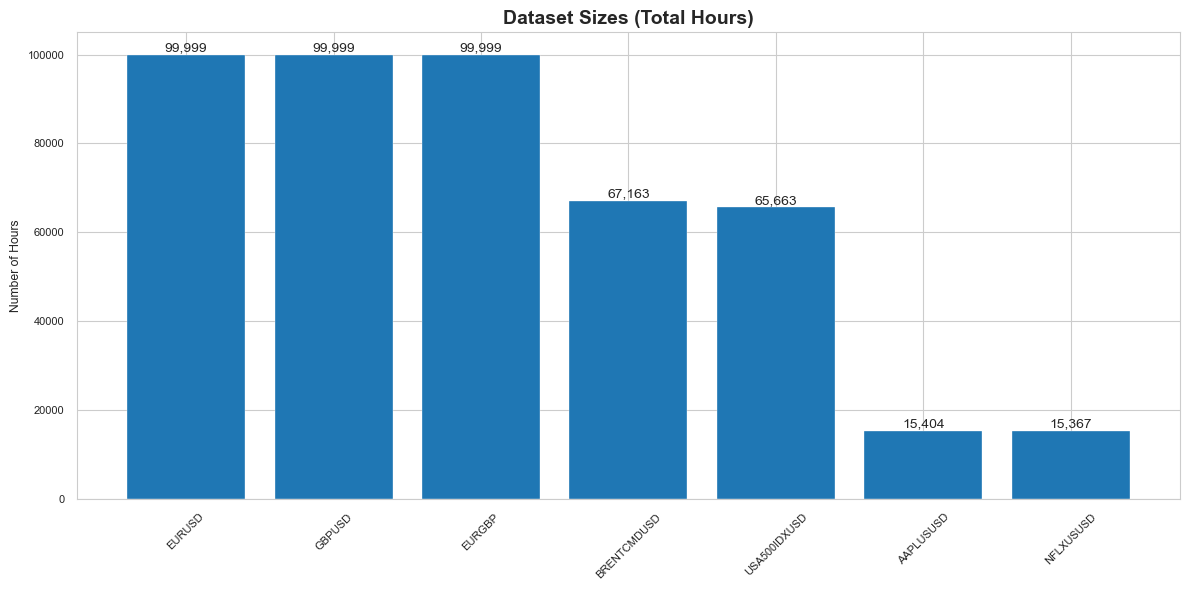

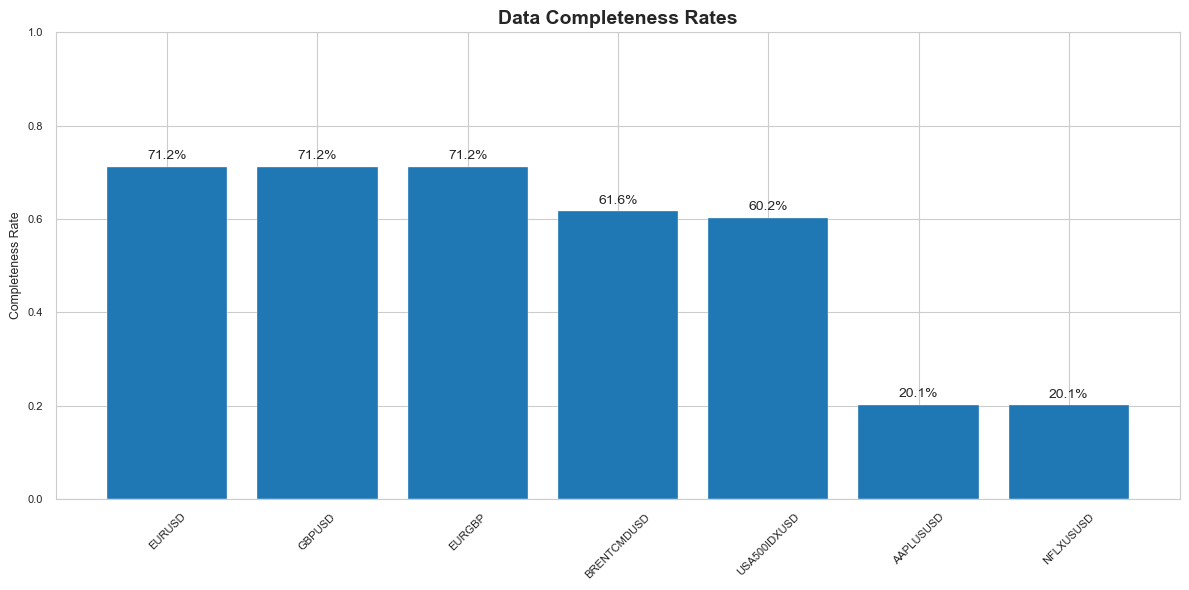

In [5]:
# Create comparison dataframe
comparison_data = []

for name, df in datasets.items():
    # Calculate basic statistics
    start_date = df.index.min()
    end_date = df.index.max()
    total_hours = len(df)
    date_range_days = (end_date - start_date).days
    expected_hours = date_range_days * 24  # Assuming 24 hours per day
    completeness = total_hours / expected_hours if expected_hours > 0 else 0

    # Check for missing values
    missing_values = df.isnull().sum().sum()

    # Check for duplicates
    duplicates = df.index.duplicated().sum()

    # Price statistics
    price_range = df['High'].max() - df['Low'].min()
    avg_volume = df['Volume'].mean()

    comparison_data.append({
        'Dataset': name.replace('_H1', ''),
        'Description': datasets_info[name],
        'Start_Date': start_date,
        'End_Date': end_date,
        'Total_Hours': total_hours,
        'Date_Range_Days': date_range_days,
        'Completeness_Rate': completeness,
        'Missing_Values': missing_values,
        'Duplicates': duplicates,
        'Price_Range': price_range,
        'Avg_Volume': avg_volume,
        'Min_Price': df['Low'].min(),
        'Max_Price': df['High'].max()
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Total_Hours', ascending=False)

# Display comparison table
print("Dataset Comparison Summary")
print("=" * 80)
display(comparison_df.round(4))

# Visualize dataset sizes
plt.figure(figsize=(12, 6))
bars = plt.bar(comparison_df['Dataset'], comparison_df['Total_Hours'])
plt.title('Dataset Sizes (Total Hours)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Hours')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Visualize completeness rates
plt.figure(figsize=(12, 6))
completeness_bars = plt.bar(comparison_df['Dataset'], comparison_df['Completeness_Rate'])
plt.title('Data Completeness Rates', fontsize=14, fontweight='bold')
plt.ylabel('Completeness Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add percentage labels
for bar in completeness_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Price Characteristics Analysis

Analyze price movements, volatility, and distribution patterns across datasets.

Price Characteristics Analysis


,Dataset,Daily_Volatility,Hourly_Volatility,Positive_Ratio,ATR,Avg_Spread_Pct,Price_Range_Pct,Skewness,Kurtosis,Max_Drawdown
0,EURUSD,0.005400,0.001100,0.497700,0.001700,0.001400,0.471200,0.013600,14.927400,-0.370000
1,GBPUSD,0.005700,0.001200,0.498500,0.002100,0.001500,0.487500,-1.490200,85.119800,-0.394500
2,EURGBP,0.004900,0.001000,0.494800,0.001100,0.001300,0.302600,0.974300,42.326200,-0.249100
3,AAPLUSUSD,0.044300,0.009000,0.522300,1.520300,0.007300,2.174400,-36.105500,2969.057900,-0.793000
4,NFLXUSUSD,0.048200,0.009800,0.504700,4.829400,0.010500,2.592000,-2.880500,152.713400,-0.762100
5,BRENTCMDUSD,0.024900,0.005100,0.500200,0.398200,0.005900,1.647600,0.195300,98.898800,-0.861300
6,USA500IDXUSD,0.011600,0.002400,0.520100,8.868500,0.002500,1.549800,-0.821100,84.785500,-0.354300


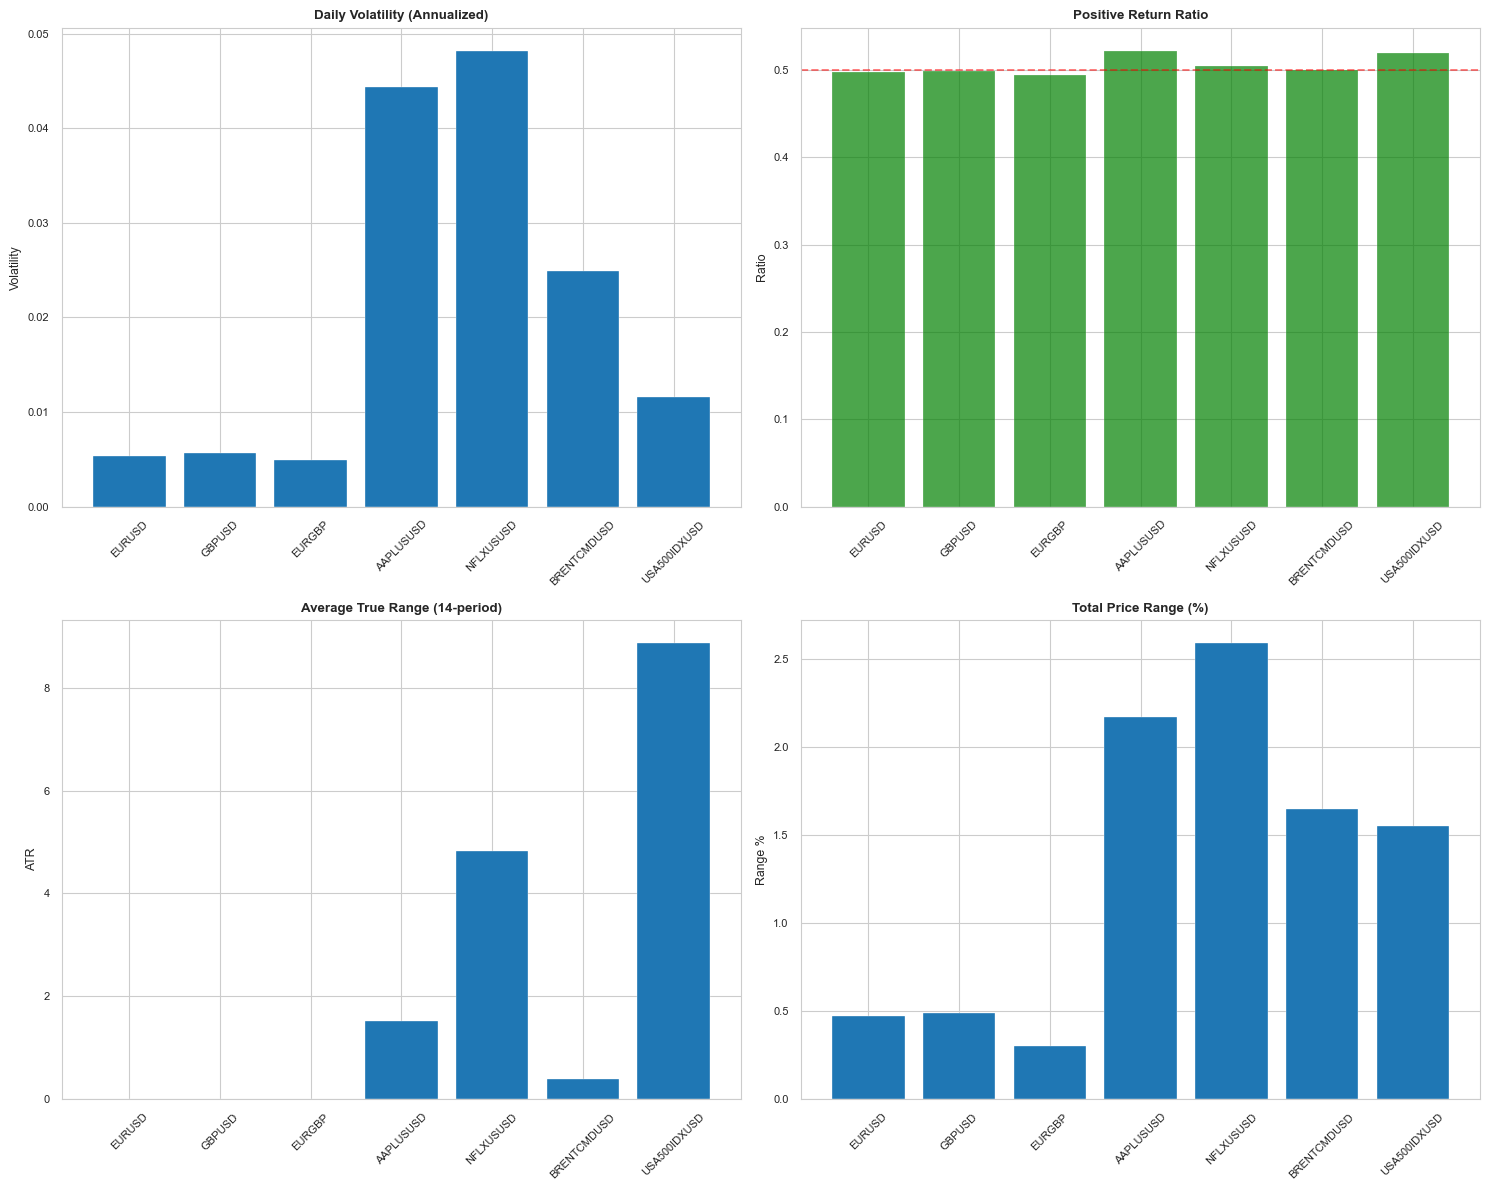

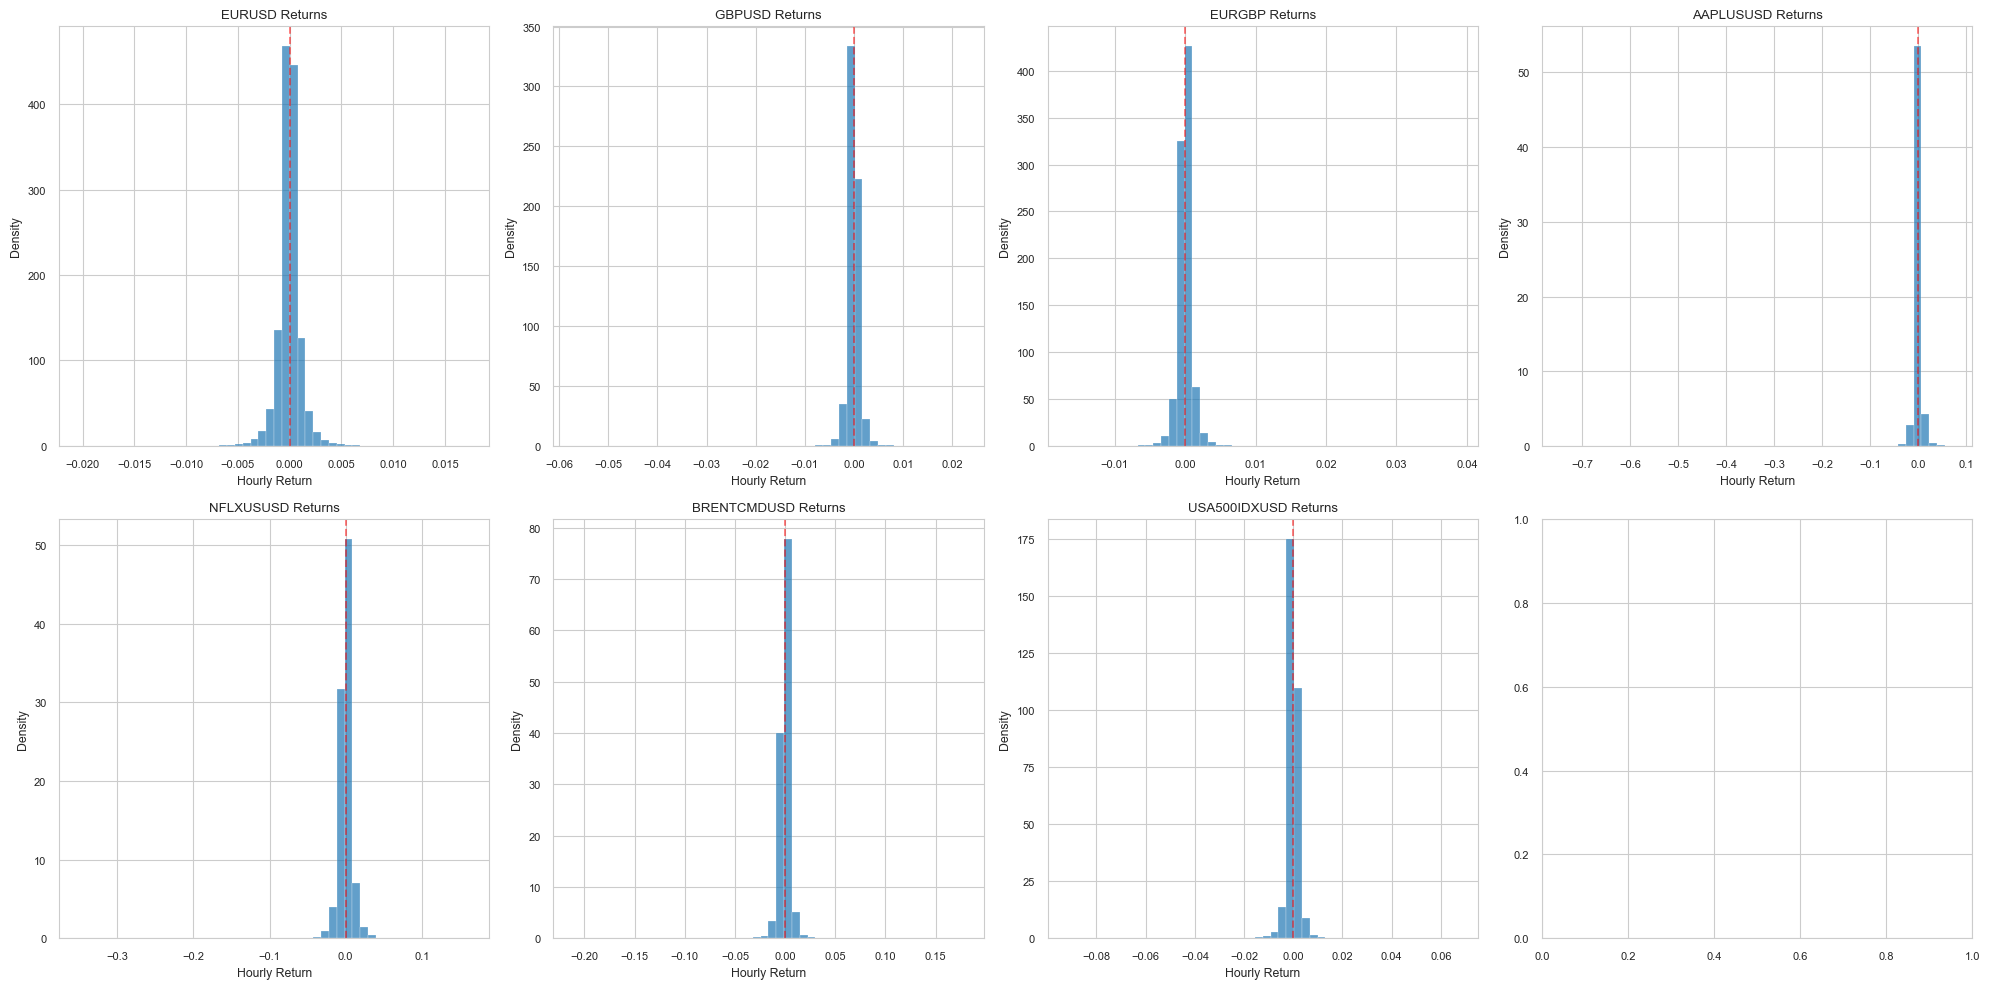

In [7]:
# Calculate price characteristics for each dataset
def calculate_max_drawdown(prices):
    """Calculate maximum drawdown from price series"""
    cumulative = (1 + prices.pct_change()).cumprod()
    running_max = cumulative.expanding().max()
    drawdowns = cumulative / running_max - 1
    return drawdowns.min()

price_analysis = []

for name, df in datasets.items():
    # Calculate returns
    df['Returns'] = df['Close'].pct_change()
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

    # Calculate volatility measures
    daily_volatility = df['Returns'].std() * np.sqrt(24)  # Annualized hourly volatility
    hourly_volatility = df['Returns'].std()

    # Price movement statistics
    positive_hours = (df['Returns'] > 0).sum()
    negative_hours = (df['Returns'] < 0).sum()
    positive_ratio = positive_hours / len(df)

    # Average true range (volatility measure)
    df['TR'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(
            abs(df['High'] - df['Close'].shift(1)),
            abs(df['Low'] - df['Close'].shift(1))
        )
    )
    atr = df['TR'].rolling(14).mean().mean()

    # Price range and spread measures
    avg_spread = ((df['High'] - df['Low']) / df['Close']).mean()
    price_range_pct = (df['High'].max() - df['Low'].min()) / df['Close'].mean()

    price_analysis.append({
        'Dataset': name.replace('_H1', ''),
        'Daily_Volatility': daily_volatility,
        'Hourly_Volatility': hourly_volatility,
        'Positive_Ratio': positive_ratio,
        'ATR': atr,
        'Avg_Spread_Pct': avg_spread,
        'Price_Range_Pct': price_range_pct,
        'Skewness': df['Returns'].skew(),
        'Kurtosis': df['Returns'].kurtosis(),
        'Max_Drawdown': calculate_max_drawdown(df['Close'])
    })

price_df = pd.DataFrame(price_analysis)

print("Price Characteristics Analysis")
print("=" * 80)
display(price_df.round(4))

# Visualize volatility comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Daily Volatility
bars1 = ax1.bar(price_df['Dataset'], price_df['Daily_Volatility'])
ax1.set_title('Daily Volatility (Annualized)', fontweight='bold')
ax1.set_ylabel('Volatility')
ax1.tick_params(axis='x', rotation=45)

# Positive Ratio
bars2 = ax2.bar(price_df['Dataset'], price_df['Positive_Ratio'], color='green', alpha=0.7)
ax2.set_title('Positive Return Ratio', fontweight='bold')
ax2.set_ylabel('Ratio')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Average True Range
bars3 = ax3.bar(price_df['Dataset'], price_df['ATR'])
ax3.set_title('Average True Range (14-period)', fontweight='bold')
ax3.set_ylabel('ATR')
ax3.tick_params(axis='x', rotation=45)

# Price Range Percentage
bars4 = ax4.bar(price_df['Dataset'], price_df['Price_Range_Pct'])
ax4.set_title('Total Price Range (%)', fontweight='bold')
ax4.set_ylabel('Range %')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Returns distribution comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    if i < 7:  # Only 7 datasets
        returns = df['Returns'].dropna()
        axes[i].hist(returns, bins=50, alpha=0.7, density=True)
        axes[i].set_title(f'{name.replace("_H1", "")} Returns')
        axes[i].set_xlabel('Hourly Return')
        axes[i].set_ylabel('Density')
        axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Volume Analysis

Compare volume patterns, distributions, and relationships with price movements across datasets.

Volume Analysis Summary


,Dataset,Volume_Mean,Volume_CV,Volume_Skewness,Volume_Kurtosis,Vol_Return_Corr,Vol_Price_Corr,High_Volume_Ratio,Volume_Trend
0,EURUSD,9953.066900,1.062300,6.138700,191.831200,0.267600,-0.195100,0.037000,NaN
1,GBPUSD,6870.486100,0.925500,13.324700,924.987000,0.375500,-0.065800,0.036500,NaN
2,EURGBP,6672.431000,0.953800,3.059800,17.395700,0.362300,0.169000,0.043900,NaN
3,AAPLUSUSD,115.280300,0.653200,1.582300,2.838400,0.141400,0.115100,0.054000,NaN
4,NFLXUSUSD,1330.132400,4.703100,5.872500,38.432400,0.031700,0.027200,0.039200,NaN
5,BRENTCMDUSD,58.920100,2.082700,70.602800,5493.013700,0.010900,0.034400,0.000500,NaN
6,USA500IDXUSD,54.867800,0.218200,-2.732300,7.938100,0.172200,0.152300,0.000900,NaN


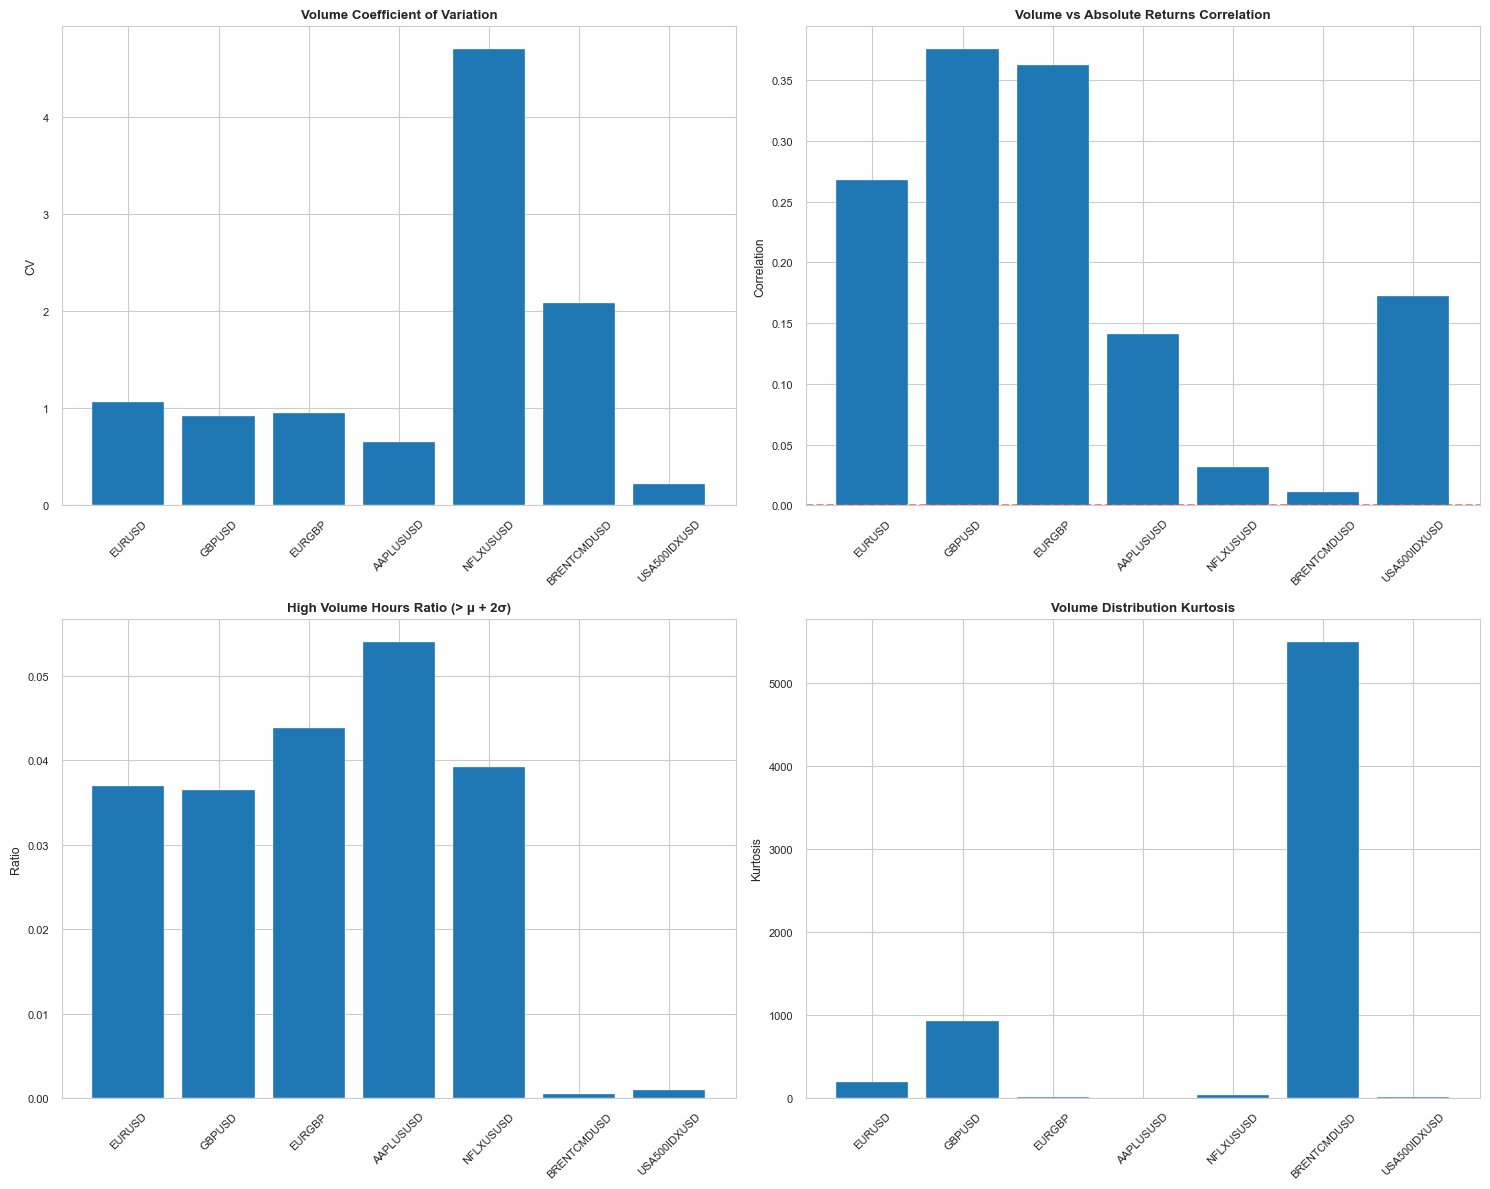

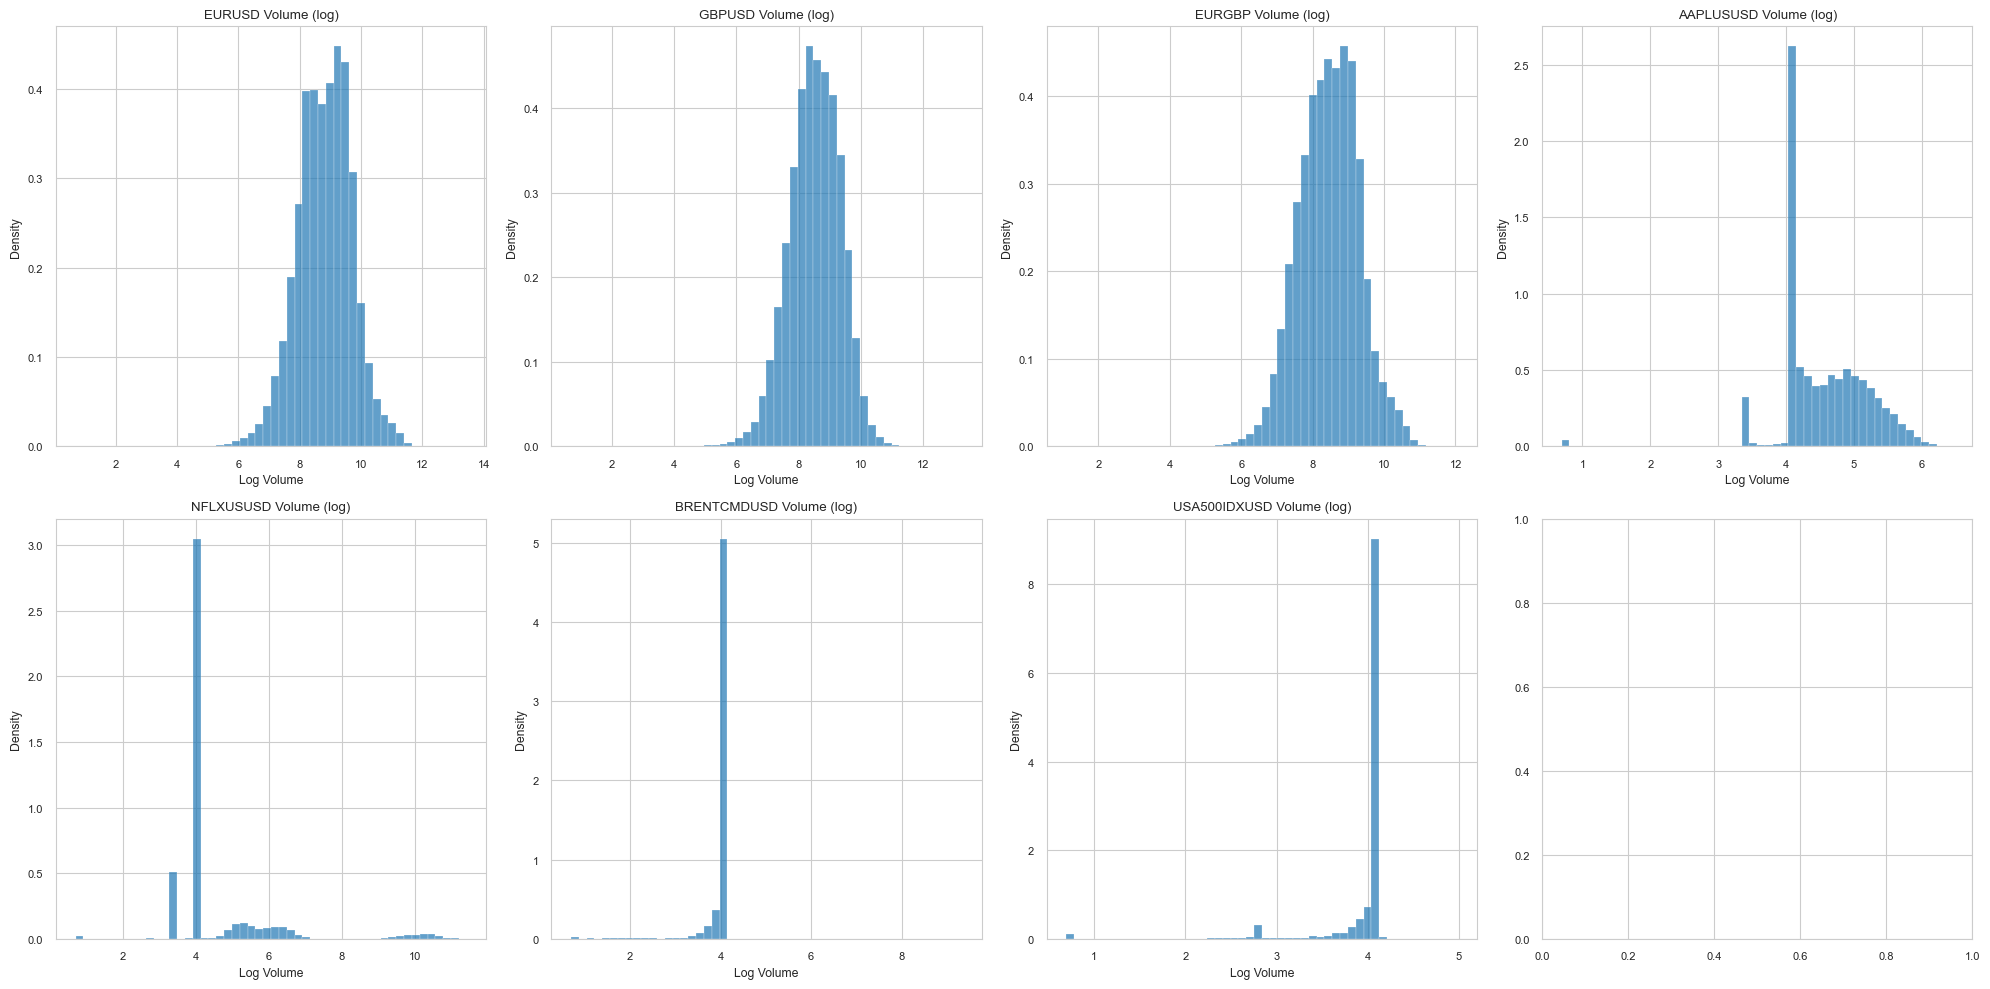

In [8]:
# Volume analysis across datasets
volume_analysis = []

for name, df in datasets.items():
    # Volume statistics
    volume_mean = df['Volume'].mean()
    volume_std = df['Volume'].std()
    volume_cv = volume_std / volume_mean if volume_mean > 0 else 0  # Coefficient of variation

    # Volume distribution characteristics
    volume_skew = df['Volume'].skew()
    volume_kurtosis = df['Volume'].kurtosis()

    # Volume-price relationships
    volume_return_corr = df['Volume'].corr(df['Returns'].abs())
    volume_price_corr = df['Volume'].corr(df['Close'])

    # Volume patterns
    high_volume_threshold = volume_mean + 2 * volume_std
    high_volume_hours = (df['Volume'] > high_volume_threshold).sum()
    high_volume_ratio = high_volume_hours / len(df)

    # Volume trends
    volume_ma_50 = df['Volume'].rolling(50).mean()
    volume_trend = (volume_ma_50.iloc[-1] / volume_ma_50.iloc[0] - 1) if len(volume_ma_50) > 1 else 0

    volume_analysis.append({
        'Dataset': name.replace('_H1', ''),
        'Volume_Mean': volume_mean,
        'Volume_CV': volume_cv,
        'Volume_Skewness': volume_skew,
        'Volume_Kurtosis': volume_kurtosis,
        'Vol_Return_Corr': volume_return_corr,
        'Vol_Price_Corr': volume_price_corr,
        'High_Volume_Ratio': high_volume_ratio,
        'Volume_Trend': volume_trend
    })

volume_df = pd.DataFrame(volume_analysis)

print("Volume Analysis Summary")
print("=" * 80)
display(volume_df.round(4))

# Visualize volume characteristics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Volume Coefficient of Variation
bars1 = ax1.bar(volume_df['Dataset'], volume_df['Volume_CV'])
ax1.set_title('Volume Coefficient of Variation', fontweight='bold')
ax1.set_ylabel('CV')
ax1.tick_params(axis='x', rotation=45)

# Volume-Return Correlation
bars2 = ax2.bar(volume_df['Dataset'], volume_df['Vol_Return_Corr'])
ax2.set_title('Volume vs Absolute Returns Correlation', fontweight='bold')
ax2.set_ylabel('Correlation')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

# High Volume Ratio
bars3 = ax3.bar(volume_df['Dataset'], volume_df['High_Volume_Ratio'])
ax3.set_title('High Volume Hours Ratio (> μ + 2σ)', fontweight='bold')
ax3.set_ylabel('Ratio')
ax3.tick_params(axis='x', rotation=45)

# Volume Kurtosis
bars4 = ax4.bar(volume_df['Dataset'], volume_df['Volume_Kurtosis'])
ax4.set_title('Volume Distribution Kurtosis', fontweight='bold')
ax4.set_ylabel('Kurtosis')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Volume distribution comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    if i < 7:
        volume_data = df['Volume']
        # Use log scale for better visualization
        log_volume = np.log1p(volume_data)
        axes[i].hist(log_volume, bins=50, alpha=0.7, density=True)
        axes[i].set_title(f'{name.replace("_H1", "")} Volume (log)')
        axes[i].set_xlabel('Log Volume')
        axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

## Time Series Properties Analysis

Examine stationarity, autocorrelation, and other time series characteristics that may affect ML model performance.

Time Series Properties Analysis


,Dataset,Is_Stationary,ADF_Statistic,ADF_P_Value,Significant_ACF_Lags,Has_Autocorr,Vol_Clustering,Trend_Strength,Hourly_Seasonality
0,EURUSD,True,-184.339700,0.000000,3,True,0.243600,0.000000,4.495000
1,GBPUSD,True,-122.160600,0.000000,5,True,0.259500,0.000000,3.415600
2,EURGBP,True,-131.849900,0.000000,8,True,0.268200,0.000000,5.303700
3,AAPLUSUSD,True,-47.266200,0.000000,5,False,0.092000,0.000000,2.993900
4,NFLXUSUSD,True,-38.701900,0.000000,1,True,0.134100,0.000100,2.897000
5,BRENTCMDUSD,True,-76.776800,0.000000,9,True,0.279000,0.000000,4.496000
6,USA500IDXUSD,True,-77.214200,0.000000,9,True,0.326500,0.000000,4.591900


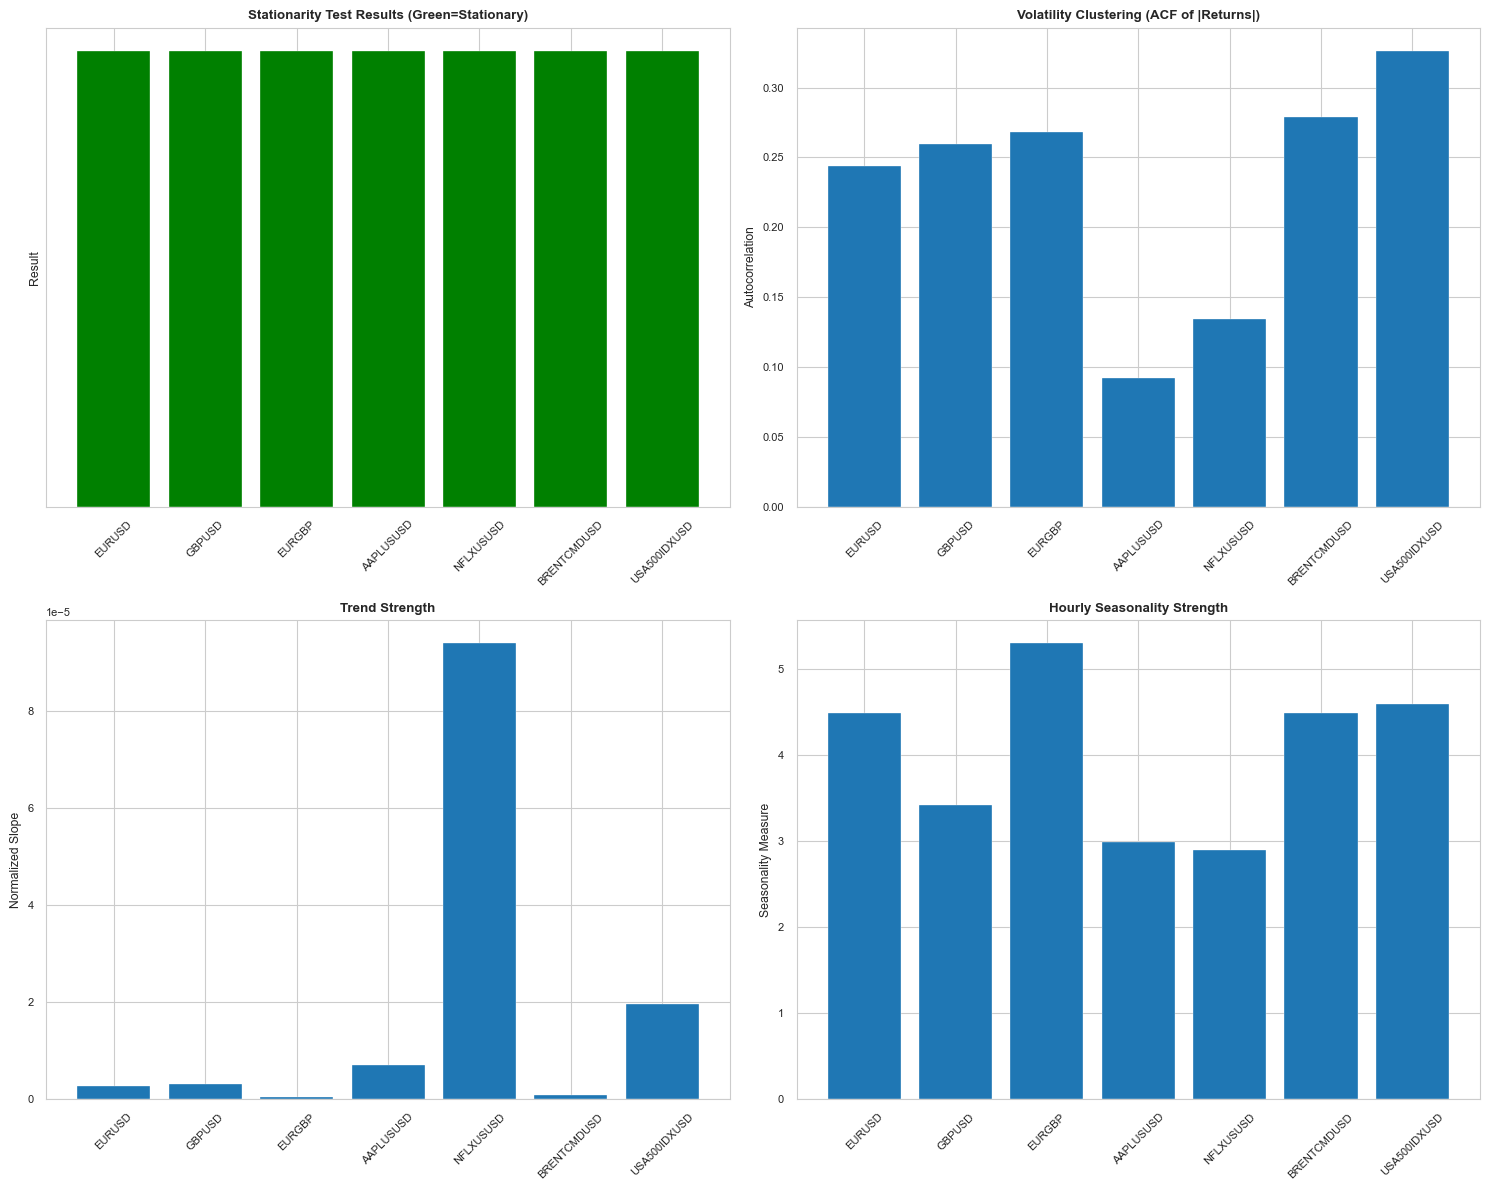

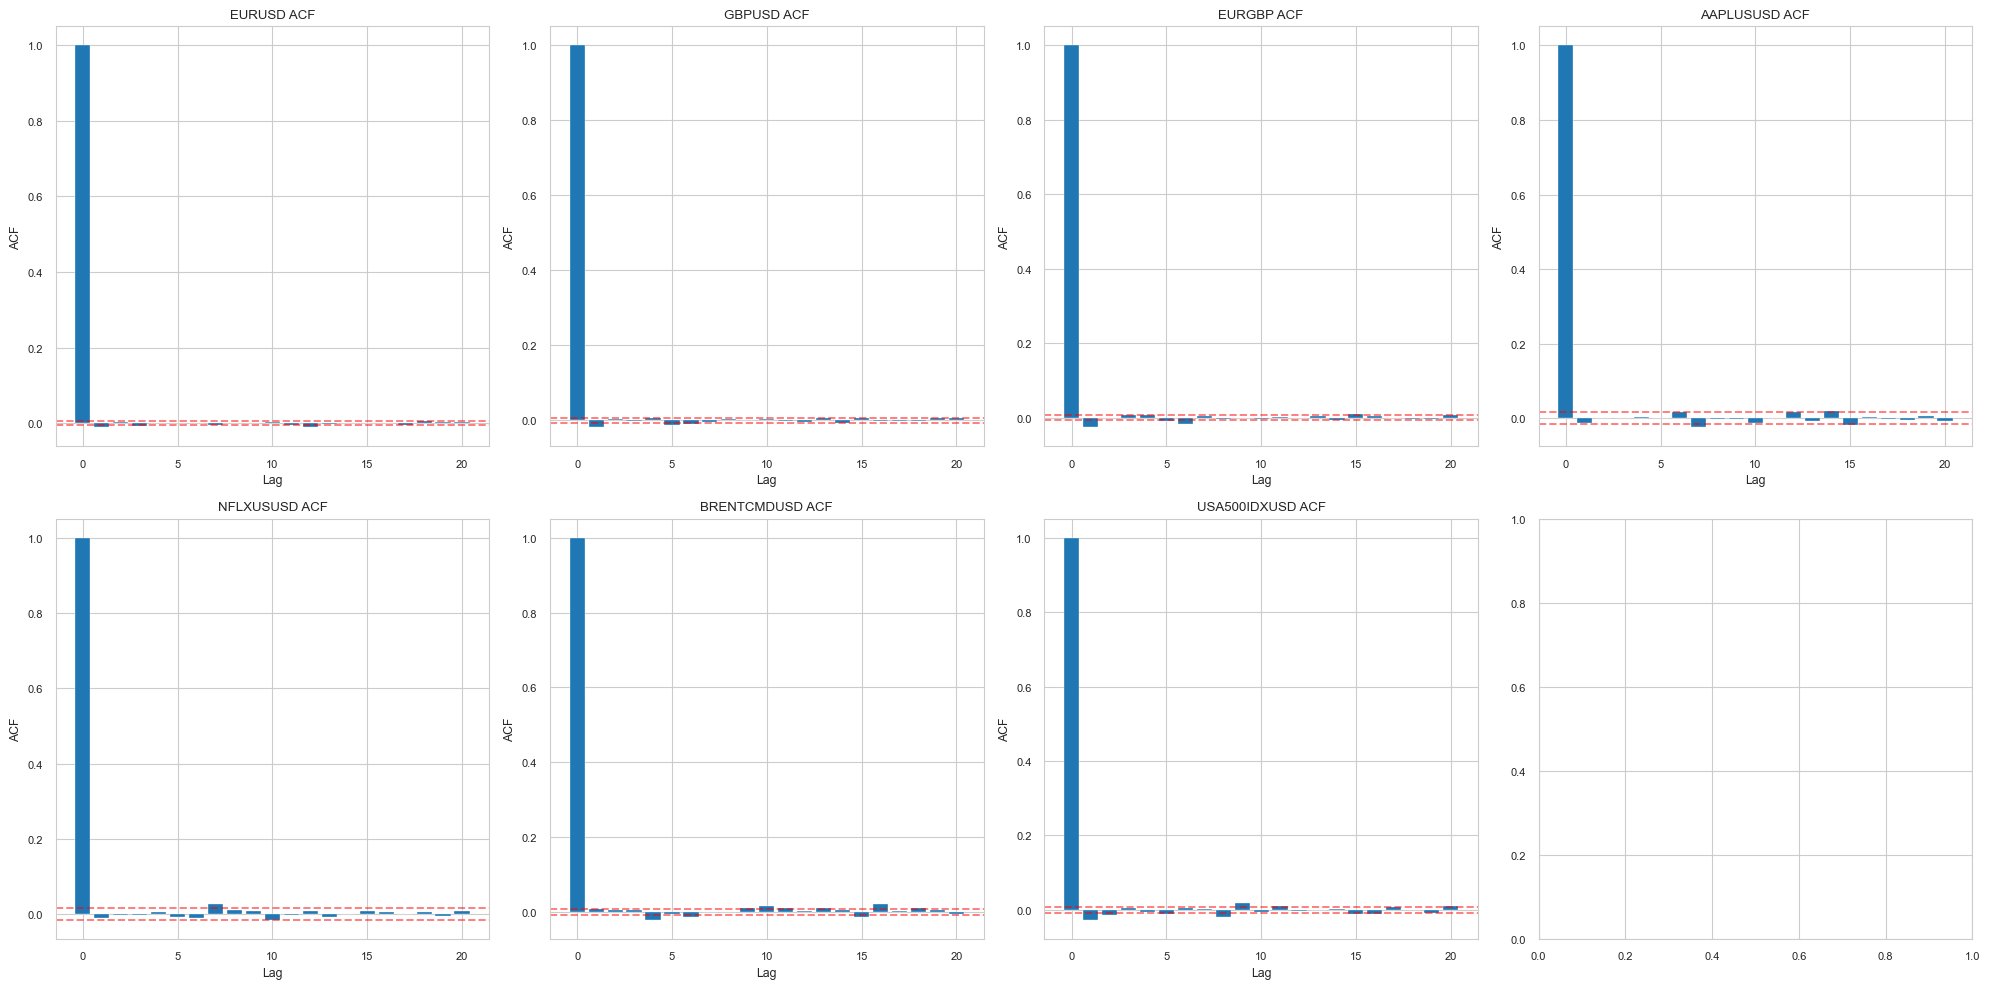

In [9]:
# Time series properties analysis
ts_analysis = []

for name, df in datasets.items():
    returns = df['Returns'].dropna()

    # Stationarity test (ADF test)
    try:
        adf_result = adfuller(returns, maxlag=10)
        adf_stat = adf_result[0]
        adf_pvalue = adf_result[1]
        is_stationary = adf_pvalue < 0.05
    except:
        adf_stat = np.nan
        adf_pvalue = np.nan
        is_stationary = False

    # Autocorrelation analysis
    try:
        acf_values = acf(returns, nlags=20, fft=True)
        significant_acf = np.sum(np.abs(acf_values[1:]) > 1.96/np.sqrt(len(returns)))
    except:
        significant_acf = 0

    # Ljung-Box test for autocorrelation
    try:
        lb_result = acorr_ljungbox(returns, lags=[10], return_df=True)
        lb_pvalue = lb_result['lb_pvalue'].iloc[0]
        has_autocorr = lb_pvalue < 0.05
    except:
        lb_pvalue = np.nan
        has_autocorr = False

    # Volatility clustering (autocorrelation of absolute returns)
    abs_returns = returns.abs()
    try:
        vol_cluster_acf = acf(abs_returns, nlags=5, fft=True)[1]  # Lag 1 autocorrelation
    except:
        vol_cluster_acf = 0

    # Trend analysis
    prices = df['Close']
    trend_slope = np.polyfit(range(len(prices)), prices, 1)[0]
    trend_strength = abs(trend_slope) / prices.mean()

    # Seasonality check (hourly patterns)
    df['Hour'] = df.index.hour
    hourly_avg_returns = df.groupby('Hour')['Returns'].mean()
    hourly_volatility = df.groupby('Hour')['Returns'].std()
    hourly_seasonality = (hourly_avg_returns.max() - hourly_avg_returns.min()) / hourly_avg_returns.std()

    ts_analysis.append({
        'Dataset': name.replace('_H1', ''),
        'Is_Stationary': is_stationary,
        'ADF_Statistic': adf_stat,
        'ADF_P_Value': adf_pvalue,
        'Significant_ACF_Lags': significant_acf,
        'Has_Autocorr': has_autocorr,
        'Vol_Clustering': vol_cluster_acf,
        'Trend_Strength': trend_strength,
        'Hourly_Seasonality': hourly_seasonality
    })

ts_df = pd.DataFrame(ts_analysis)

print("Time Series Properties Analysis")
print("=" * 80)
display(ts_df.round(4))

# Visualize stationarity results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Stationarity (color coded)
colors = ['green' if x else 'red' for x in ts_df['Is_Stationary']]
bars1 = ax1.bar(ts_df['Dataset'], [1] * len(ts_df), color=colors)
ax1.set_title('Stationarity Test Results (Green=Stationary)', fontweight='bold')
ax1.set_ylabel('Result')
ax1.tick_params(axis='x', rotation=45)
ax1.set_yticks([])

# Volatility Clustering
bars2 = ax2.bar(ts_df['Dataset'], ts_df['Vol_Clustering'])
ax2.set_title('Volatility Clustering (ACF of |Returns|)', fontweight='bold')
ax2.set_ylabel('Autocorrelation')
ax2.tick_params(axis='x', rotation=45)

# Trend Strength
bars3 = ax3.bar(ts_df['Dataset'], ts_df['Trend_Strength'])
ax3.set_title('Trend Strength', fontweight='bold')
ax3.set_ylabel('Normalized Slope')
ax3.tick_params(axis='x', rotation=45)

# Hourly Seasonality
bars4 = ax4.bar(ts_df['Dataset'], ts_df['Hourly_Seasonality'])
ax4.set_title('Hourly Seasonality Strength', fontweight='bold')
ax4.set_ylabel('Seasonality Measure')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Autocorrelation comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    if i < 7:
        returns = df['Returns'].dropna()
        try:
            acf_vals = acf(returns, nlags=20, fft=True)
            axes[i].bar(range(21), acf_vals)
            axes[i].set_title(f'{name.replace("_H1", "")} ACF')
            axes[i].set_xlabel('Lag')
            axes[i].set_ylabel('ACF')
            axes[i].axhline(y=1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
            axes[i].axhline(y=-1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
        except:
            axes[i].text(0.5, 0.5, 'ACF Error', ha='center', va='center', transform=axes[i].transAxes)

plt.tight_layout()
plt.show()

## Key Insights and Implications for ML Performance

Based on the comprehensive analysis above, here are the key structural differences between datasets that may influence prediction performance:

🔍 KEY INSIGHTS FOR ML PIPELINE PERFORMANCE
.1f
.1f
.1f
• Stationarity: 7/7 datasets show stationary returns
  → Non-stationary series may require differencing or specialized models
.1f
• Autocorrelation: 6 datasets show significant autocorrelation: ['EURUSD', 'GBPUSD', 'EURGBP', 'NFLXUSUSD', 'BRENTCMDUSD', 'USA500IDXUSD']
  → May benefit from ARIMA-type features or require careful cross-validation
• Volatility Clustering: Strong clustering in ['EURUSD', 'GBPUSD', 'EURGBP', 'NFLXUSUSD', 'BRENTCMDUSD', 'USA500IDXUSD']
  → GARCH-type models or volatility-based features may be beneficial

📊 PREDICTION PERFORMANCE IMPLICATIONS:
--------------------------------------------------
• Small datasets (['USA500IDXUSD', 'AAPLUSUSD', 'NFLXUSUSD']) may suffer from overfitting
  → Consider data augmentation or simpler models
• High volatility datasets (['AAPLUSUSD', 'NFLXUSUSD', 'BRENTCMDUSD']) may have more predictable patterns
  → May benefit from volatility-based features
• Incomplete datasets (['E

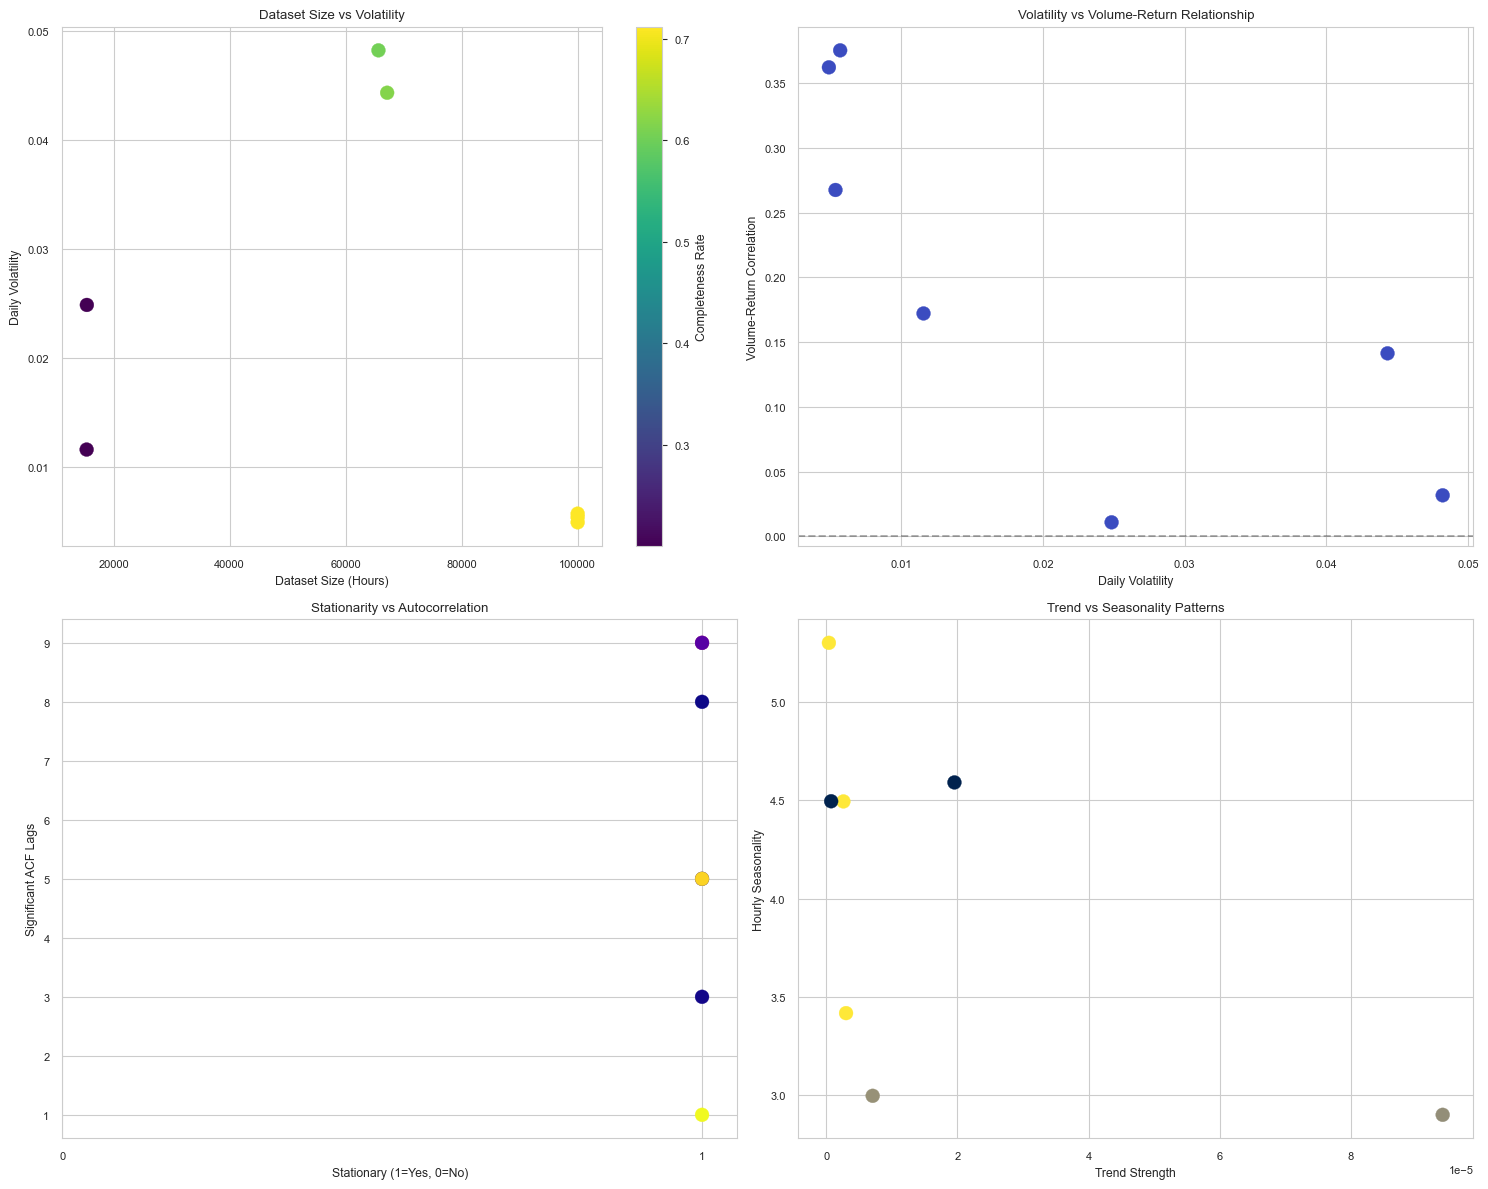


📈 CONCLUSION
The datasets show significant structural heterogeneity that likely explains
the varying performance in your metaheuristics pipeline. Key factors include:
• Dataset size and completeness differences
• Volatility and return distribution characteristics
• Time series properties (stationarity, autocorrelation)
• Volume patterns and their relationship to price movements
• Asset class-specific behaviors

Consider these factors when interpreting GA feature selection results
and model performance comparisons across different datasets.


In [13]:
# Generate insights based on the analysis
print("🔍 KEY INSIGHTS FOR ML PIPELINE PERFORMANCE")
print("=" * 80)

# Dataset size differences
size_variation = comparison_df['Total_Hours'].max() / comparison_df['Total_Hours'].min()
print(".1f")

# Volatility differences
vol_variation = price_df['Daily_Volatility'].max() / price_df['Daily_Volatility'].min()
print(".1f")

# Completeness differences
completeness_range = comparison_df['Completeness_Rate'].max() - comparison_df['Completeness_Rate'].min()
print(".1f")

# Stationarity differences
stationary_count = ts_df['Is_Stationary'].sum()
print(f"• Stationarity: {stationary_count}/{len(ts_df)} datasets show stationary returns")
print("  → Non-stationary series may require differencing or specialized models")

# Volume characteristics
high_vol_variation = volume_df['Volume_CV'].max() / volume_df['Volume_CV'].min()
print(".1f")

# Autocorrelation patterns
autocorr_datasets = ts_df[ts_df['Has_Autocorr']]['Dataset'].tolist()
print(f"• Autocorrelation: {len(autocorr_datasets)} datasets show significant autocorrelation: {autocorr_datasets}")
print("  → May benefit from ARIMA-type features or require careful cross-validation")

# Volatility clustering
clustering_datasets = ts_df[ts_df['Vol_Clustering'] > 0.1]['Dataset'].tolist()
print(f"• Volatility Clustering: Strong clustering in {clustering_datasets}")
print("  → GARCH-type models or volatility-based features may be beneficial")

print("\n📊 PREDICTION PERFORMANCE IMPLICATIONS:")
print("-" * 50)

# Size implications
small_datasets = comparison_df[comparison_df['Total_Hours'] < comparison_df['Total_Hours'].median()]['Dataset'].tolist()
print(f"• Small datasets ({small_datasets}) may suffer from overfitting")
print("  → Consider data augmentation or simpler models")

# High volatility implications
high_vol_datasets = price_df[price_df['Daily_Volatility'] > price_df['Daily_Volatility'].median()]['Dataset'].tolist()
print(f"• High volatility datasets ({high_vol_datasets}) may have more predictable patterns")
print("  → May benefit from volatility-based features")

# Completeness implications
incomplete_datasets = comparison_df[comparison_df['Completeness_Rate'] < 0.8]['Dataset'].tolist()
if incomplete_datasets:
    print(f"• Incomplete datasets ({incomplete_datasets}) may have data quality issues")
    print("  → Consider imputation or gap-filling strategies")

# Asset class differences
fx_datasets = ['EURUSD', 'GBPUSD', 'EURGBP']
equity_datasets = ['AAPL', 'NFLX']
commodity_datasets = ['BRENTCMD']
index_datasets = ['USA500IDX']

print("\n🎯 ASSET CLASS CHARACTERISTICS:")
print(f"• FX Pairs ({fx_datasets}): Typically lower volatility, high frequency, strong autocorrelation")
print(f"• Equities ({equity_datasets}): Higher volatility, potential non-trading hours gaps")
print(f"• Commodities ({commodity_datasets}): Supply/demand driven, potential extreme events")
print(f"• Indices ({index_datasets}): Broad market representation, high completeness")

print("🔧 RECOMMENDATIONS FOR METAHEURISTICS PIPELINE:")
print("2. Evaluate GA performance separately per dataset due to structural differences")
print("3. Use time-series aware cross-validation for all datasets")
print("4. Consider volatility scaling/normalization for comparability")
print("5. Investigate if data completeness affects feature selection stability")

# Create summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Dataset sizes vs volatility
scatter1 = ax1.scatter(comparison_df['Total_Hours'], price_df['Daily_Volatility'],
                      c=comparison_df['Completeness_Rate'], cmap='viridis', s=100)
ax1.set_xlabel('Dataset Size (Hours)')
ax1.set_ylabel('Daily Volatility')
ax1.set_title('Dataset Size vs Volatility')
plt.colorbar(scatter1, ax=ax1, label='Completeness Rate')

# Volatility vs volume correlation
ax2.scatter(price_df['Daily_Volatility'], volume_df['Vol_Return_Corr'],
           c=ts_df['Is_Stationary'].astype(int), cmap='coolwarm', s=100)
ax2.set_xlabel('Daily Volatility')
ax2.set_ylabel('Volume-Return Correlation')
ax2.set_title('Volatility vs Volume-Return Relationship')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Stationarity vs autocorrelation
ax3.scatter(ts_df['Is_Stationary'].astype(int), ts_df['Significant_ACF_Lags'],
           c=price_df['Daily_Volatility'], cmap='plasma', s=100)
ax3.set_xlabel('Stationary (1=Yes, 0=No)')
ax3.set_ylabel('Significant ACF Lags')
ax3.set_title('Stationarity vs Autocorrelation')
ax3.set_xticks([0, 1])

# Trend strength vs seasonality
ax4.scatter(ts_df['Trend_Strength'], ts_df['Hourly_Seasonality'],
           c=comparison_df['Total_Hours'], cmap='cividis', s=100)
ax4.set_xlabel('Trend Strength')
ax4.set_ylabel('Hourly Seasonality')
ax4.set_title('Trend vs Seasonality Patterns')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📈 CONCLUSION")
print("=" * 80)
print("The datasets show significant structural heterogeneity that likely explains")
print("the varying performance in your metaheuristics pipeline. Key factors include:")
print("• Dataset size and completeness differences")
print("• Volatility and return distribution characteristics")
print("• Time series properties (stationarity, autocorrelation)")
print("• Volume patterns and their relationship to price movements")
print("• Asset class-specific behaviors")
print("\nConsider these factors when interpreting GA feature selection results")
print("and model performance comparisons across different datasets.")